# 02 — Heuristic Markov Chain
Label each 1-hour bar into one of three LP regimes using percentile thresholds on `realised_vol` and `total_fees_usd`. Estimate and visualise the transition matrix.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import pickle

FEATURES_PATH = Path('../data/hourly_features.parquet')
SCALER_PATH   = Path('../data/scaler_params.pkl')

STATE_NAMES   = ['Goldilocks', 'Trending', 'Toxic']
STATE_COLORS  = {'Goldilocks': '#2ecc71', 'Trending': '#f39c12', 'Toxic': '#e74c3c'}

## 1. Load & Standardise

In [2]:
df = pd.read_parquet(FEATURES_PATH)
print(df.shape, list(df.columns))
df.head(3)

(42301, 9) ['window', 'swap_count', 'price_first', 'price_last', 'tick_std', 'abs_amount0_sum', 'log_return', 'realised_vol', 'total_fees_usd']


,window,swap_count,price_first,price_last,tick_std,abs_amount0_sum,log_return,realised_vol,total_fees_usd
0,0,1,3402.943362,3402.943362,NaN,119744094,0.0000,0.000000,0.059872
1,1,7,3524.501462,3523.444323,29.920530,5536905883,-0.0003,29.920530,2.768453
2,2,11,3522.739740,3489.782775,84.151487,15284529734,-0.0094,84.151487,7.642265


In [3]:
FEATURE_COLS = ['log_return', 'swap_count', 'total_fees_usd', 'realised_vol']

# Fit standardisation on the full series
means = df[FEATURE_COLS].mean()
stds  = df[FEATURE_COLS].std().replace(0, 1)  # avoid div-by-zero

df_std = df.copy()
df_std[FEATURE_COLS] = (df[FEATURE_COLS] - means) / stds

# Persist scaler params for use in notebook 03
with open(SCALER_PATH, 'wb') as f:
    pickle.dump({'means': means, 'stds': stds}, f)
print('Scaler params saved.')
df_std[FEATURE_COLS].describe().round(3)

Scaler params saved.


,log_return,swap_count,total_fees_usd,realised_vol
count,42301.000,42301.000,42301.000,42301.000
mean,0.000,-0.000,0.000,0.000
std,1.000,1.000,1.000,1.000
min,-25.154,-1.949,-0.771,-0.902
25%,-0.356,-0.634,-0.571,-0.516
50%,0.013,-0.211,-0.311,-0.257
75%,0.370,0.375,0.196,0.184
max,36.519,14.861,25.660,51.279


## 2. Define regime thresholds (fee-efficiency percentile-based)

We first compute:

\[
\text{fee\_efficiency} = \frac{\text{total\_fees\_usd}}{\text{realised\_vol} + \epsilon}, \quad \epsilon = 10^{-6}
\]

Then use percentile cutoffs on `fee_efficiency`:

| State | Condition |
|-------|-----------|
| **Goldilocks** | `fee_efficiency` ≥ 67th percentile (`fe_p67`) |
| **Toxic** | `fee_efficiency` ≤ 33rd percentile (`fe_p33`) |
| **Trending** | everything else |

In [12]:
EPSILON = 1e-6  # avoid div-by-zero on zero-vol windows

df['fee_efficiency'] = df['total_fees_usd'] / (df['realised_vol'] + EPSILON)

fe_p33 = df['fee_efficiency'].quantile(0.33)
fe_p67 = df['fee_efficiency'].quantile(0.67)

print(f'fee_efficiency  p33={fe_p33:.4f}  p67={fe_p67:.4f}')

def label_state(row):
    fe = row['fee_efficiency']
    if fe >= fe_p67:
        return 'Goldilocks'
    if fe <= fe_p33:
        return 'Toxic'
    return 'Trending'

df['heuristic_state'] = df.apply(label_state, axis=1)
print('\nState counts:')
print(df['heuristic_state'].value_counts())

fee_efficiency  p33=174.1673  p67=359.6025

State counts:
heuristic_state
Trending      14381
Goldilocks    13960
Toxic         13960
Name: count, dtype: int64


## 3. Transition matrix

In [13]:
# Count consecutive state pairs
from_states = df['heuristic_state'].iloc[:-1].values
to_states   = df['heuristic_state'].iloc[1:].values

trans_counts = pd.crosstab(
    pd.Series(from_states, name='From'),
    pd.Series(to_states,   name='To'),
    normalize='index'
).reindex(index=STATE_NAMES, columns=STATE_NAMES, fill_value=0)

trans_counts.round(3)

To,Goldilocks,Trending,Toxic
From,,,
Goldilocks,0.618,0.334,0.048
Trending,0.321,0.476,0.203
Toxic,0.052,0.206,0.743


## 4. Visualisations

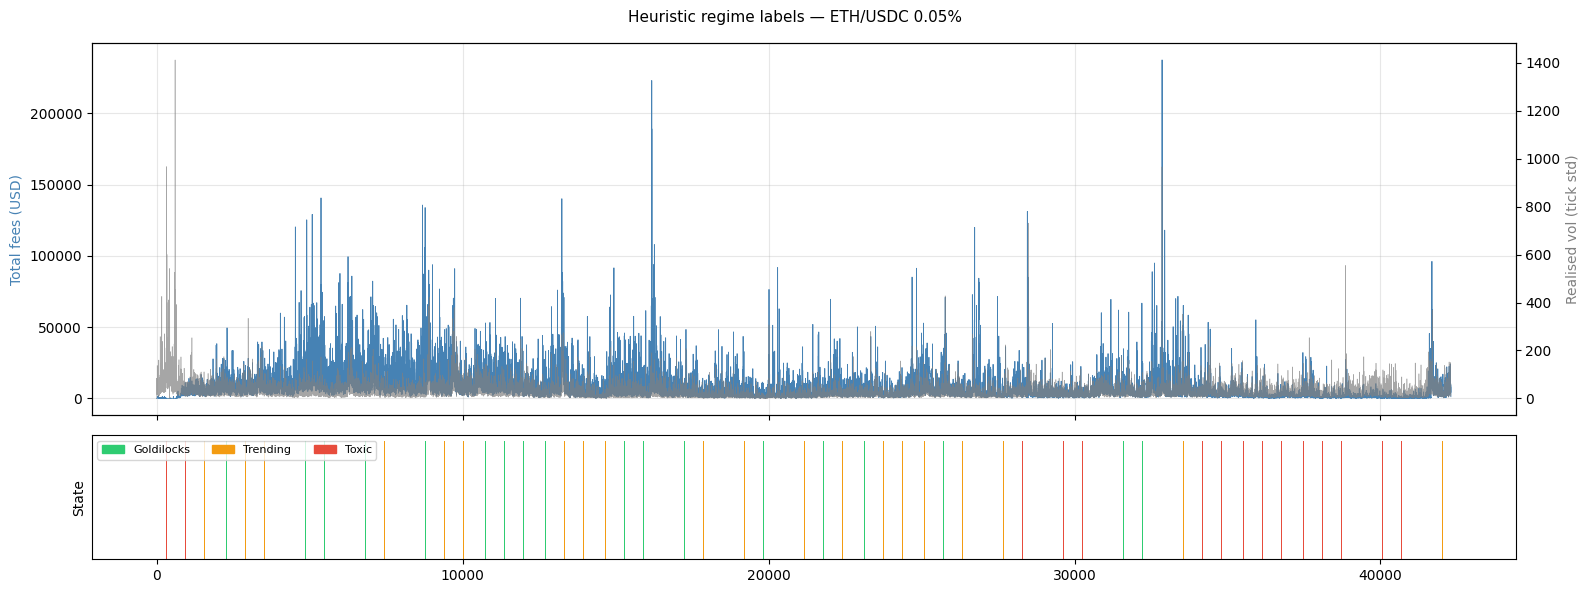

In [14]:
# --- 4a. Regime timeline ---
state_int = df['heuristic_state'].map({'Goldilocks': 0, 'Trending': 1, 'Toxic': 2})

fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})

# Feature panel
ax0 = axes[0]
ax0.plot(df['window'], df['total_fees_usd'], color='steelblue', lw=0.6, label='Fees (USD)')
ax0.set_ylabel('Total fees (USD)', color='steelblue')
ax0_twin = ax0.twinx()
ax0_twin.plot(df['window'], df['realised_vol'], color='grey', lw=0.4, alpha=0.7, label='Vol')
ax0_twin.set_ylabel('Realised vol (tick std)', color='grey')
ax0.grid(alpha=0.3)

# State band
ax1 = axes[1]
colors_mapped = df['heuristic_state'].map(STATE_COLORS)
ax1.bar(df['window'], np.ones(len(df)), width=1/24, color=colors_mapped, linewidth=0)
ax1.set_yticks([])
ax1.set_ylabel('State')
patches = [mpatches.Patch(color=v, label=k) for k, v in STATE_COLORS.items()]
ax1.legend(handles=patches, loc='upper left', fontsize=8, ncol=3)

fig.suptitle('Heuristic regime labels — ETH/USDC 0.05%', fontsize=11)
plt.tight_layout()
plt.show()

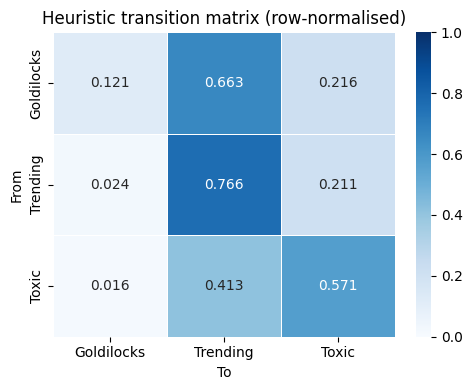

In [7]:
# --- 4b. Transition matrix heatmap ---
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(trans_counts, annot=True, fmt='.3f', cmap='Blues',
            linewidths=0.5, ax=ax, vmin=0, vmax=1)
ax.set_title('Heuristic transition matrix (row-normalised)')
plt.tight_layout()
plt.show()

C:\Users\PC\AppData\Local\Temp\ipykernel_11120\4205425495.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=STATE_NAMES, patch_artist=True, showfliers=False)
C:\Users\PC\AppData\Local\Temp\ipykernel_11120\4205425495.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=STATE_NAMES, patch_artist=True, showfliers=False)
C:\Users\PC\AppData\Local\Temp\ipykernel_11120\4205425495.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=STATE_NAMES, patch_artist=True, showfliers=False)
C:\Users\PC\AppData\Local\Temp\ipykernel_11120\4205425495.

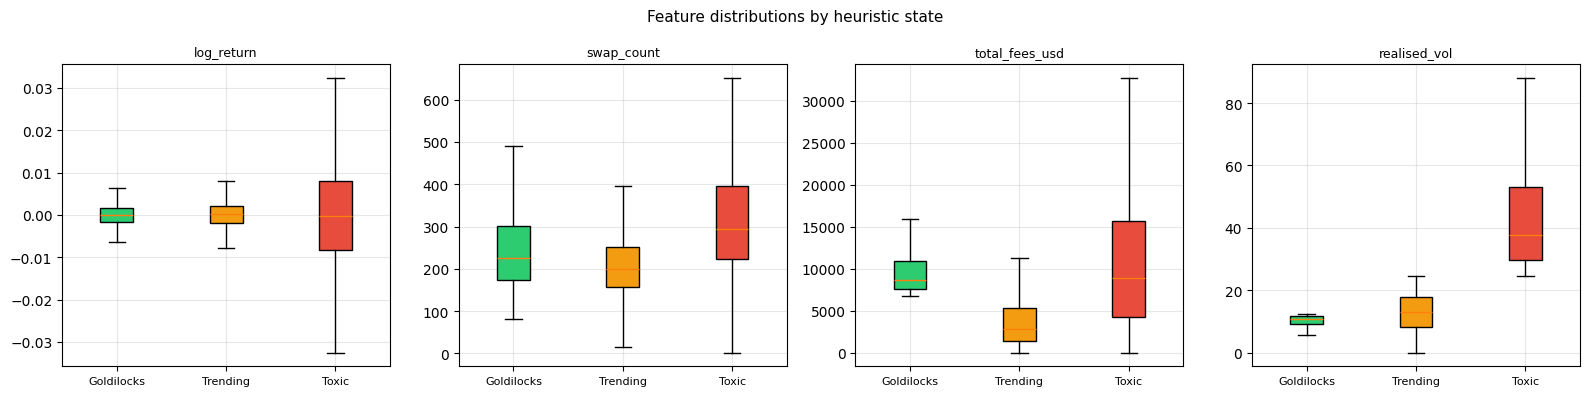

In [8]:
# --- 4c. Feature distributions per state ---
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, FEATURE_COLS):
    data = [df.loc[df['heuristic_state'] == s, col].values for s in STATE_NAMES]
    bp = ax.boxplot(data, labels=STATE_NAMES, patch_artist=True, showfliers=False)
    for patch, s in zip(bp['boxes'], STATE_NAMES):
        patch.set_facecolor(STATE_COLORS[s])
    ax.set_title(col, fontsize=9)
    ax.tick_params(axis='x', labelsize=8)
    ax.grid(alpha=0.3)
plt.suptitle('Feature distributions by heuristic state', fontsize=11)
plt.tight_layout()
plt.show()

In [9]:
# --- Summary statistics per state ---
df.groupby('heuristic_state')[FEATURE_COLS].mean().round(4)

,log_return,swap_count,total_fees_usd,realised_vol
heuristic_state,,,,
Goldilocks,-0.0000,248.1134,10687.8790,10.1572
Toxic,-0.0002,324.7347,12120.5320,47.6788
Trending,0.0001,211.9543,4137.6925,13.0261


In [10]:
# Save labelled df for comparison in notebook 03
df.to_parquet(Path('../data/hourly_features_labelled.parquet'), index=False)
print('Saved hourly_features_labelled.parquet')

Saved hourly_features_labelled.parquet
